In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from narwhals.selectors import categorical
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
import shap
import optuna
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split

In [45]:
application_train = pd.read_csv("train_features.csv")
application_test = pd.read_csv("test_features.csv")

In [46]:
application_train.shape

(307511, 177)

In [47]:
application_test.shape

(48744, 176)

In [48]:
application_train.head()

,Unnamed: 0,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,...,max_amt_application,mean_amt_credit,max_amt_credit,mean_percentage_recieved,mean_amt_down_payment,max_amt__down_payment,prev_application_count,prev_approved,prev_refused,prev_approval_rate
0,0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,...,179055.0,179055.00,179055.0,0.999994,0.00,0.0,1.0,1.0,0.0,1.000000
1,1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,...,900000.0,484191.00,1035882.0,1.057658,3442.50,6885.0,3.0,3.0,0.0,1.000000
2,2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,...,24282.0,20106.00,20106.0,0.827987,4860.00,4860.0,1.0,1.0,0.0,1.000000
3,3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,...,688500.0,291695.50,906615.0,1.012677,34840.17,66987.0,9.0,5.0,1.0,0.555556
4,4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,...,247500.0,166638.75,284400.0,1.046339,3390.75,3676.5,6.0,6.0,0.0,1.000000


In [49]:
application_test.head()

,Unnamed: 0,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,max_amt_application,mean_amt_credit,max_amt_credit,mean_percentage_recieved,mean_amt_down_payment,max_amt__down_payment,prev_application_count,prev_approved,prev_refused,prev_approval_rate
0,0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,...,24835.5,23787.000,23787.0,0.957744,2520.0,2520.0,1.0,1.0,0.0,1.00
1,1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,...,44617.5,20076.750,40153.5,0.899929,4464.0,4464.0,2.0,1.0,0.0,0.50
2,2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,...,450000.0,146134.125,512370.0,1.052340,3375.0,6750.0,4.0,3.0,0.0,0.75
3,3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,...,130765.5,92920.500,225000.0,0.967465,3750.0,11250.0,5.0,3.0,0.0,0.60
4,4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,...,454500.0,300550.500,508495.5,1.131349,8095.5,8095.5,2.0,1.0,0.0,0.50


In [50]:
application_train.drop(columns=["Unnamed: 0"], inplace=True)
application_test.drop(columns=["Unnamed: 0"], inplace=True)

In [51]:
y = application_train["TARGET"]
X = application_train.drop("TARGET", axis=1)

In [52]:
numerical_cols = X.select_dtypes(include="number").columns.tolist()
categorical_cols = X.select_dtypes(exclude="number").columns.tolist()

In [53]:
print(len(numerical_cols))
print(len(categorical_cols))

159
16


In [54]:
categorical_cols

['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [55]:
for col in categorical_cols:
    X[col] = X[col].astype('category')
    application_test[col] = application_test[col].astype('category')

In [56]:
import re
[col for col in X.columns if re.search(r'[^A-Za-z0-9_]', col)]

[]

In [57]:
X.dtypes[X.dtypes == 'object']

Series([], dtype: object)

In [58]:
#Probieren wir es zuerst mit einem LightGBM

In [59]:
GBM = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31
)
GBM.fit(X, y)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [60]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(GBM, X, y, cv=cv, n_jobs=-1, scoring="roc_auc")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.307660 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21867
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 171
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.169320 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_

In [61]:
scores.mean()
#Output: 0.7758985820151467

np.float64(0.7750757192336339)

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

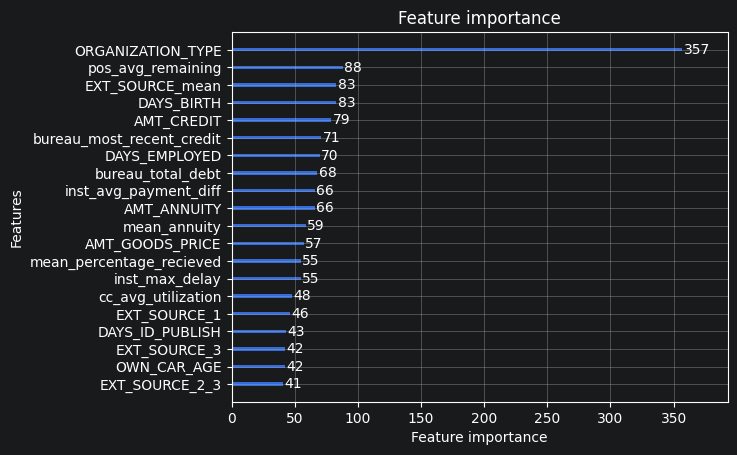

In [62]:
lgb.plot_importance(GBM, max_num_features=20)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


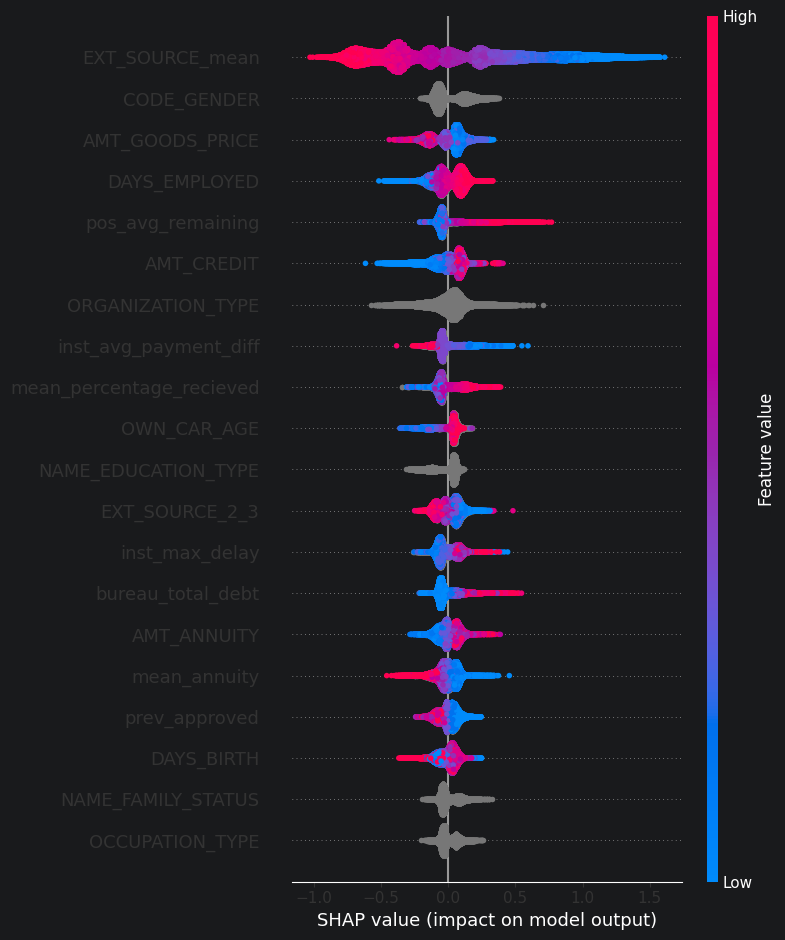

In [63]:
explainer = shap.TreeExplainer(GBM)
shap_values = explainer.shap_values(X)

# Global: welche Features sind insgesamt wichtig
shap.summary_plot(shap_values, X, max_display=20)

In [64]:
def submission(model):
    X_test = application_test.copy()
    predictions = model.predict_proba(X_test)[:, 1]  # Wahrscheinlichkeit für Klasse 1

    # Submission erstellen
    submission = pd.DataFrame({
        "SK_ID_CURR": application_test["SK_ID_CURR"],
        "TARGET": predictions
    })
    return submission

In [23]:
#Besseres Boosting Model:

In [24]:
def objective(trial):
    params = {
        'num_leaves': trial.suggest_int('num_leaves', 20, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'n_estimators': 1000,  # hohes Maximum – Early Stopping stoppt früher
        'random_state': 42,
        'verbose': -1,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=-1),  # Output unterdrücken
            ]
        )

        preds = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, preds))

    return np.mean(auc_scores)

In [35]:
study = optuna.create_study(
    direction='maximize',
    storage="sqlite:///lgbm_study.db",
    study_name="lgbm",
    load_if_exists=True
)

study.optimize(objective, n_trials=100)

print(study.best_params)
print(study.best_value)

[I 2026-05-07 17:55:30,550] A new study created in memory with name: no-name-a2422466-f619-44ac-925f-96ca987f6623
[W 2026-05-07 17:55:33,277] Trial 0 failed with parameters: {'num_leaves': 25, 'learning_rate': 0.018169674189824635, 'min_child_samples': 48, 'subsample': 0.6271916951024514, 'colsample_bytree': 0.9784301847476435, 'reg_alpha': 6.582742651011339e-06, 'reg_lambda': 5.785519680408504e-05} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/p3/cbztfpt14vz2k7ybs5qwp4040000gn/T/ipykernel_75649/4289265923.py", line 23, in objective
    model.fit(
    ~~~~~~~~~^
        X_tr, y_tr,
        ^^^^^^^^^^^
    ...<4 lines>...
        ]
        ^
    )
    ^
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/lightgbm/sklea

KeyboardInterrupt: 

In [26]:
application_train["mean_percentage_recieved"].describe()

count    290042.000000
mean          1.017685
std           0.098646
min           0.199999
25%           0.972770
50%           1.020934
75%           1.076872
max           2.000000
Name: mean_percentage_recieved, dtype: float64

In [36]:
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(X, y, test_size=0.2, random_state=42)

best_model = lgb.LGBMClassifier(**study.best_params, n_estimators=1000, random_state=42)
best_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_val_final, y_val_final)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

ValueError: No trials are completed yet.

In [ ]:
submission3 = submission(best_model)
submission3.to_csv("submission3.csv", index=False)

In [ ]:
#Baseline XGBoost

In [ ]:
application_train.select_dtypes(exclude=["number", "category"]).columns.tolist()

In [ ]:
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,        # Anzahl der Bäume
    learning_rate=0.05,       # Schrittweite (Eta)
    max_depth=6,              # Tiefe der Bäume
    subsample=0.8,            # Anteil der Daten pro Baum (Reihe)
    colsample_bytree=0.8,     # Anteil der Features pro Baum (Spalte)
    tree_method='hist',       # Nutzt Histogramm-Methode (viel schneller, ähnlich wie LightGBM)
    random_state=42,
    use_label_encoder=False,
    enable_categorical=True,
)

# Training mit Early Stopping
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)], # Validierung auf "unbekannten" Daten
    verbose=100
)

In [ ]:
submission4 = submission(xgb_model)
submission4.to_csv("submission4.csv", index=False)

In [28]:
def objectiveXGB(trial):
    params = {
        # Diese Parameter werden von Optuna optimiert
        'n_estimators': 1000,
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),

        # Wichtig für deine kategorischen Daten:
        'tree_method': 'hist',
        'enable_categorical': True,
        'random_state': 42,
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    auc_scores = []

    for train_idx, val_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = xgb.XGBClassifier(**params, early_stopping_rounds=50)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        preds = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, preds))

    return np.mean(auc_scores)

In [30]:
studyXG = optuna.create_study(
    direction='maximize',
    storage="sqlite:///xgb_study.db",
    study_name="xgb",
    load_if_exists=True
)
studyXG.optimize(objectiveXGB, n_trials=100)
print("Beste Parameter:", studyXG.best_params)

[I 2026-05-07 16:53:22,705] A new study created in memory with name: no-name-7aecc2c4-5359-44d2-8bb2-4624a7c94d2e
[I 2026-05-07 16:55:46,972] Trial 0 finished with value: 0.7806292836902896 and parameters: {'max_depth': 5, 'learning_rate': 0.022458186981773168, 'subsample': 0.5050612734708306, 'colsample_bytree': 0.5177528618813048, 'min_child_weight': 17, 'gamma': 4.18074132566428e-08}. Best is trial 0 with value: 0.7806292836902896.
[I 2026-05-07 16:56:36,506] Trial 1 finished with value: 0.7757599667476098 and parameters: {'max_depth': 9, 'learning_rate': 0.07153029030227318, 'subsample': 0.8571102666753649, 'colsample_bytree': 0.6995958944272458, 'min_child_weight': 9, 'gamma': 2.420163184233429e-07}. Best is trial 0 with value: 0.7806292836902896.
[I 2026-05-07 16:59:46,977] Trial 2 finished with value: 0.7809046729202161 and parameters: {'max_depth': 10, 'learning_rate': 0.015842941689676714, 'subsample': 0.7913648160173448, 'colsample_bytree': 0.777568405110873, 'min_child_weigh

Beste Parameter: {'max_depth': 4, 'learning_rate': 0.04348489061471542, 'subsample': 0.9076604079332934, 'colsample_bytree': 0.9783953279336345, 'min_child_weight': 9, 'gamma': 4.181153918613525e-06}


In [33]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

best_model_XG = xgb.XGBClassifier(
    **studyXG.best_params,
    n_estimators=1000,
    random_state=42,
    tree_method="hist",
    enable_categorical=True,
    early_stopping_rounds=50
)
best_model_XG.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)
print(best_model_XG.best_iteration)

[0]	validation_0-logloss:0.27846
[100]	validation_0-logloss:0.24551
[200]	validation_0-logloss:0.24131
[300]	validation_0-logloss:0.23969
[400]	validation_0-logloss:0.23869
[500]	validation_0-logloss:0.23821
[600]	validation_0-logloss:0.23790
[700]	validation_0-logloss:0.23765
[800]	validation_0-logloss:0.23748
[872]	validation_0-logloss:0.23745
822


In [34]:
submission5 = submission(best_model_XG)
submission5.to_csv("submission5.csv", index=False)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

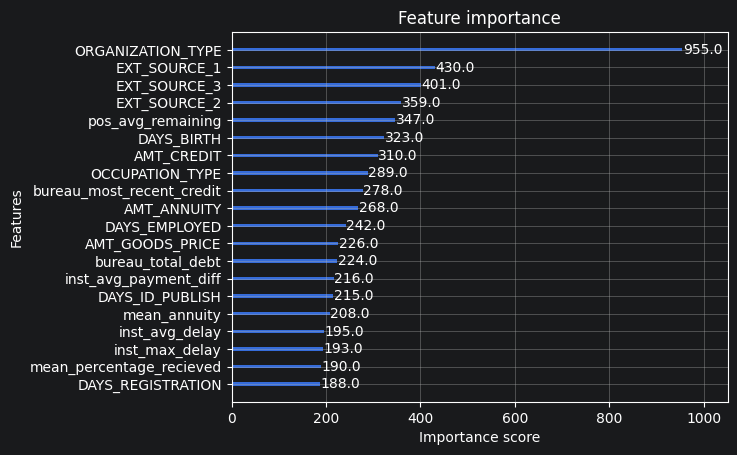

In [38]:
xgb.plot_importance(best_model_XG, max_num_features=20)